Turn time + raw acceleration into:
- Scaled (+/-1g)
- Scaled (m/s^2)
- Velocity (m/s)
- Displacement (Disp, m)
- Load (via y = a*x + b)

Also includes reverse-engineering of Excel's calibration input.

In [25]:
from dataclasses import dataclass
from typing import Iterable, Literal, Optional, Tuple
import numpy as np
import pandas as pd
# --------------------------- Data classes ---------------------------
@dataclass
class AccelCalibration:
    """
    AccelCalibration groups the parameters needed to convert
    raw accelerometer readings into physical units (g).

    Attributes
    ----------
    offset : float
        The raw sensor value that corresponds to 0 g (no acceleration).
        - Example: If your accelerometer outputs 0.345 V when stationary,
          then offset = 0.345.
        - This removes the "bias" of the sensor.

    sens : float
        The sensitivity of the sensor, i.e. how many raw units correspond
        to 1 g (≈ 9.81 m/s²).
        - Example: If a change of 0.065 V corresponds to 1 g, then sens = 0.065.
        - Higher sensitivity → larger raw change for the same acceleration.

    Usage
    -----
    scaled_g = (raw_value - offset) / sens
    scaled_mps2 = scaled_g * 9.81
    """

    offset: float = 0.0   # default: assume no bias in raw readings
    sens: float = 1.0     # default: 1 raw unit = 1 g (no scaling)


@dataclass
class LoadCalibration:
    a: float = 754.717
    b: float = -0.26717

# --------------------------- Helpers ---------------------

def _ensure_increasing_time(t: np.ndarray, *arrays: np.ndarray) -> Tuple[np.ndarray, ...]:
    if np.any(np.diff(t) <= 0):
        idx = np.argsort(t)
        out = (t[idx],) + tuple(arr[idx] for arr in arrays)
        return out
    return (t,) + arrays

def _cumtrapz_same_length(y: np.ndarray, x: np.ndarray) -> np.ndarray:
    n = len(y)
    if n < 2:
        return np.zeros_like(y, dtype=float)
    dx = np.diff(x)
    avg = 0.5 * (y[1:] + y[:-1])
    out = np.empty(n, dtype=float)
    out[0] = 0.0
    out[1:] = np.cumsum(avg * dx)
    return out

def _remove_linear_drift(vec: np.ndarray) -> np.ndarray:
    if len(vec) < 2:
        return vec
    trend = np.linspace(0.0, vec[-1], len(vec))
    return vec - trend

def compute(
    time: Iterable[float],
    accel_raw: Iterable[float],
    *,
    accel_cal: AccelCalibration = AccelCalibration(),
    use_auto_zero_mean: bool = True,
    g_const: float = 9.81,
    drift_fix_velocity: bool = True,
    load_cal: LoadCalibration = LoadCalibration(),
    load_input: Literal["raw", "scaled_g", "scaled_mps2", "external", "original"] = "raw",
    x_external_for_load: Optional[Iterable[float]] = None,
    load_original: Optional[Iterable[float]] = None,  # <--- add this
) -> pd.DataFrame:
    """
    Compute Scaled (+/-1g), Scaled (m/s^2), Velocity, Disp, and Load.
    """
    t = np.asarray(time, dtype=float)
    raw = np.asarray(accel_raw, dtype=float)
    if t.size != raw.size:
        raise ValueError("time and accel_raw must have the same length.")
    if t.size < 2:
        raise ValueError("Need at least 2 samples to integrate.")

    # sort if needed
    t, raw = _ensure_increasing_time(t, raw)

    # raw -> g
    if use_auto_zero_mean:
        scaled_g = raw - np.nanmean(raw)
    else:
        scaled_g = (raw - accel_cal.offset) / accel_cal.sens

    # g -> m/s^2
    a_mps2 = scaled_g * g_const

    # integrate a -> v
    v = _cumtrapz_same_length(a_mps2, t)
    if drift_fix_velocity:
        v = _remove_linear_drift(v)

    # integrate v -> disp
    disp = _cumtrapz_same_length(v, t)

    # choose x for load
    if load_input == "raw":
        x_for_load = raw
        load = load_cal.a * x_for_load + load_cal.b
    elif load_input == "scaled_g":
        x_for_load = scaled_g
        load = load_cal.a * x_for_load + load_cal.b
    elif load_input == "scaled_mps2":
        x_for_load = a_mps2
        load = load_cal.a * x_for_load + load_cal.b
    elif load_input == "external":
        if x_external_for_load is None:
            raise ValueError("Provide x_external_for_load for external load input")
        x_for_load = np.asarray(x_external_for_load, dtype=float)
        _, x_for_load = _ensure_increasing_time(t, x_for_load)
        load = load_cal.a * x_for_load + load_cal.b
    elif load_input == "original":
        if load_original is None:
            raise ValueError("Provide load_original when load_input='original'")
        load = np.asarray(load_original, dtype=float)
        _, load = _ensure_increasing_time(t, load)
    else:
        raise ValueError("Invalid load_input option")

    return pd.DataFrame({
        "Time (s)": t,
        "Acceleration raw": raw,
        "Load": load,
        "Scaled (+/-1g)": scaled_g,
        "Scaled (m/s2)": a_mps2,
        "Velocity (m/s)": v,
        "Disp (m)": disp,
    })


In [26]:
# The direct URL to the Google Sheet in Excel format
excel_url = "https://docs.google.com/spreadsheets/d/1C5ZyL0aE21lSYZ3Okla-TDrF57EZf-okP1N0wAhhqDQ/export?usp=sharing"


# excel_url = "https://docs.google.com/spreadsheets/d/1tB6QvbcZICpoWiWCSVcsxLrRDJynUn4JlYqvFDVJjME/export?gid=135776686#gid=135776686"
# Use pandas to read the Excel file directly from the URL
df = pd.read_excel(excel_url, engine='openpyxl')

# Create the initial Excel file with the original data
with pd.ExcelWriter('RPLTResults.xlsx') as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)

In [27]:
df.head()

,Time (s),Acceleration raw,LOAD
0,2.630039,0.000084,202.830
1,2.630098,0.000235,200.325
2,2.630156,0.000218,205.365
3,2.630215,0.000223,205.365
4,2.630273,0.000273,200.325


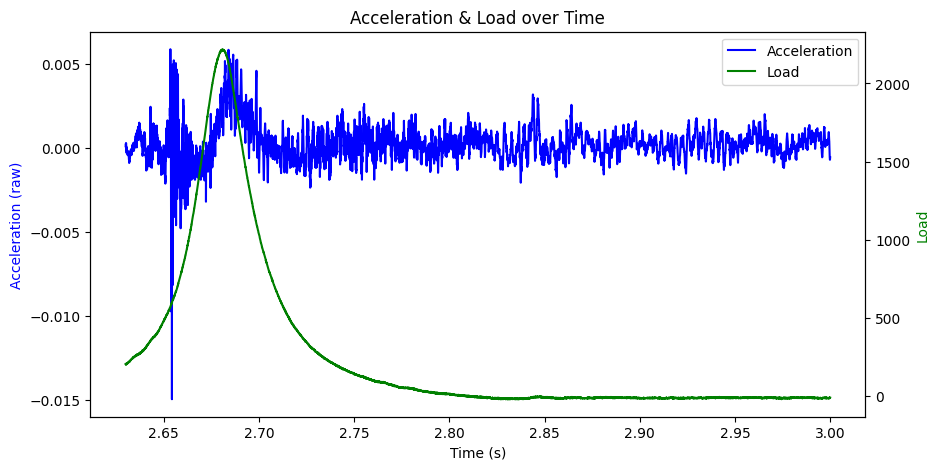

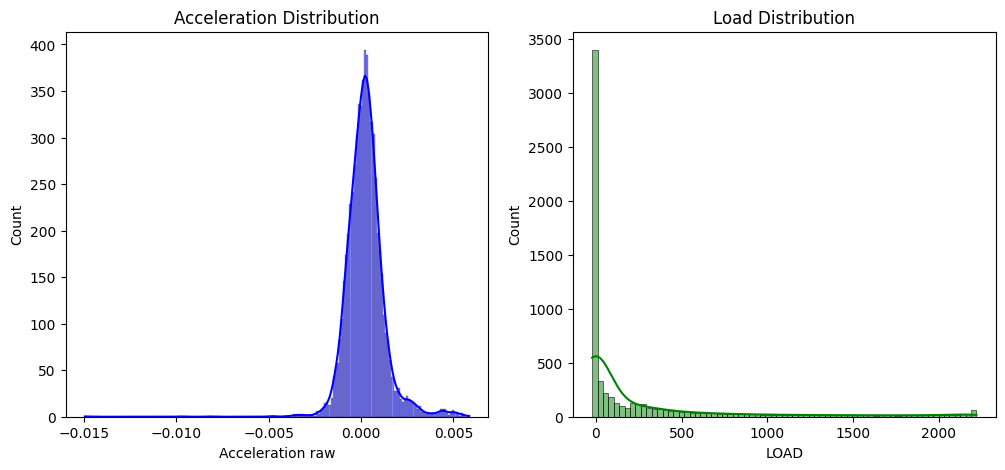

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Dual-axis line chart (best single summary for time series)
fig, ax1 = plt.subplots(figsize=(10,5))

ax2 = ax1.twinx()
ax1.plot(df['Time (s)'], df['Acceleration raw'], color='blue', label="Acceleration")
ax2.plot(df['Time (s)'], df['LOAD'], color='green', label="Load")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Acceleration (raw)", color='blue')
ax2.set_ylabel("Load", color='green')
plt.title("Acceleration & Load over Time")

# Add legends properly
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Acceleration raw'], kde=True, color='blue')
plt.title("Acceleration Distribution")

plt.subplot(1,2,2)
sns.histplot(df['LOAD'], kde=True, color='green')
plt.title("Load Distribution")
plt.show()

plt.show()


In [29]:
time = df['Time (s)'].to_list()
accel_raw = df['Acceleration raw'].to_list()
load_original = df['LOAD'].to_list()


df = compute(
    time,
    accel_raw,
    use_auto_zero_mean=True,
    load_input="original",
    load_original=load_original
)

In [30]:
df

,Time (s),Acceleration raw,Load,Scaled (+/-1g),Scaled (m/s2),Velocity (m/s),Disp (m)
0,2.630039,0.000084,202.830,-0.000162,-0.001594,0.000000e+00,0.000000e+00
1,2.630098,0.000235,200.325,-0.000011,-0.000112,-5.037669e-08,-1.486112e-12
2,2.630156,0.000218,205.365,-0.000028,-0.000279,-6.177886e-08,-4.738623e-12
3,2.630215,0.000223,205.365,-0.000023,-0.000230,-7.684935e-08,-8.828155e-12
4,2.630273,0.000273,200.325,0.000027,0.000261,-7.601845e-08,-1.326132e-11
...,...,...,...,...,...,...,...
6310,2.999766,-0.000570,-11.445,-0.000816,-0.008009,2.080427e-06,6.579277e-06
6311,2.999824,-0.000702,-13.980,-0.000948,-0.009304,1.578280e-06,6.579383e-06
6312,2.999883,-0.000719,-13.980,-0.000965,-0.009471,1.024356e-06,6.579460e-06
6313,2.999941,-0.000647,-13.980,-0.000893,-0.008765,4.954662e-07,6.579504e-06


# Load vs Displacement plot

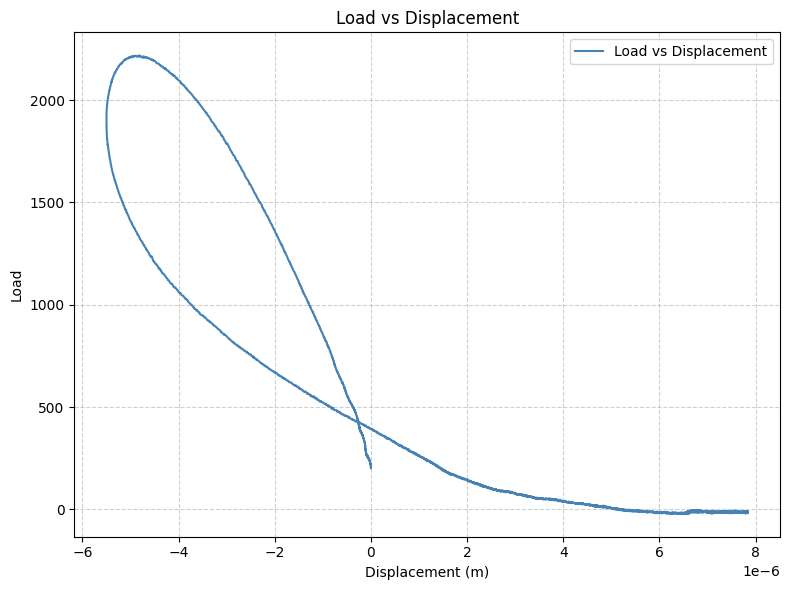

In [31]:
import matplotlib.pyplot as plt

# --- Load vs Displacement ---
# Assuming your computed DataFrame is called df_out
plt.figure(figsize=(8, 6))
plt.plot(df["Disp (m)"], df["Load"], label="Load vs Displacement", color="steelblue")

plt.title("Load vs Displacement")
plt.xlabel("Displacement (m)")
plt.ylabel("Load")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Velocity & Displacement vs Time plot

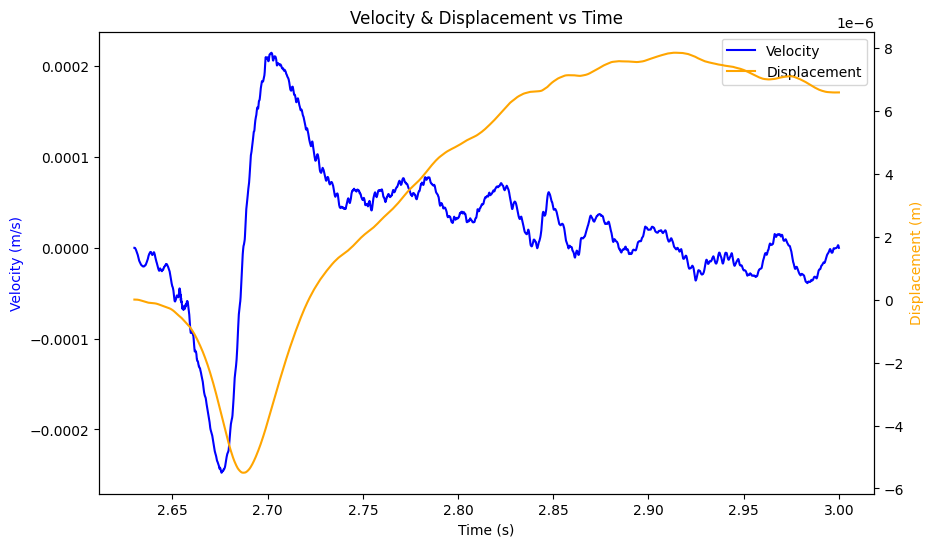

In [32]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(df["Time (s)"], df["Velocity (m/s)"], color="blue", label="Velocity")
ax2.plot(df["Time (s)"], df["Disp (m)"], color="orange", label="Displacement")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Velocity (m/s)", color="blue")
ax2.set_ylabel("Displacement (m)", color="orange")
plt.title("Velocity & Displacement vs Time")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.show()


# Acceleration & Displacement vs Time plot

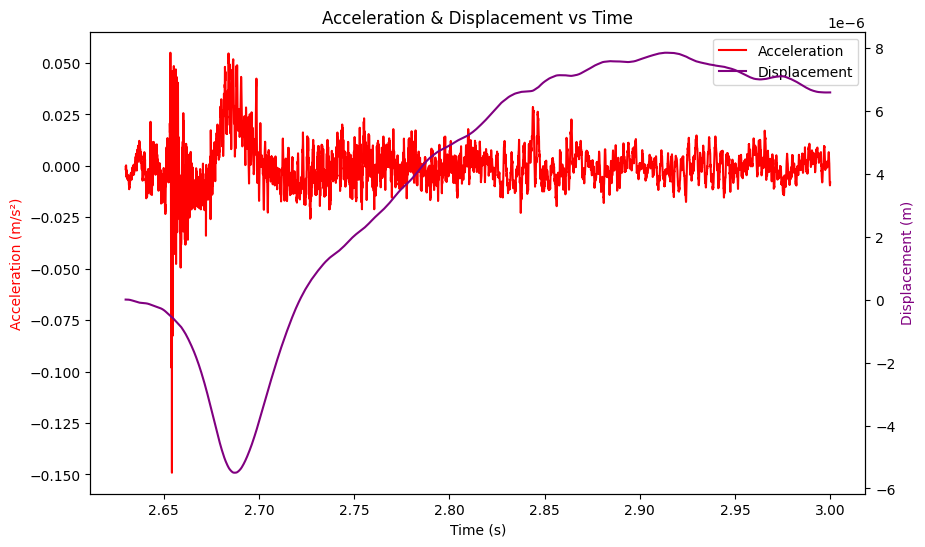

In [33]:

# --- Acceleration & Displacement vs Time ---
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(df["Time (s)"], df["Scaled (m/s2)"], color="red", label="Acceleration")
ax2.plot(df["Time (s)"], df["Disp (m)"], color="purple", label="Displacement")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Acceleration (m/s²)", color="red")
ax2.set_ylabel("Displacement (m)", color="purple")
plt.title("Acceleration & Displacement vs Time")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.show()

# Load & Displacement vs Time plot

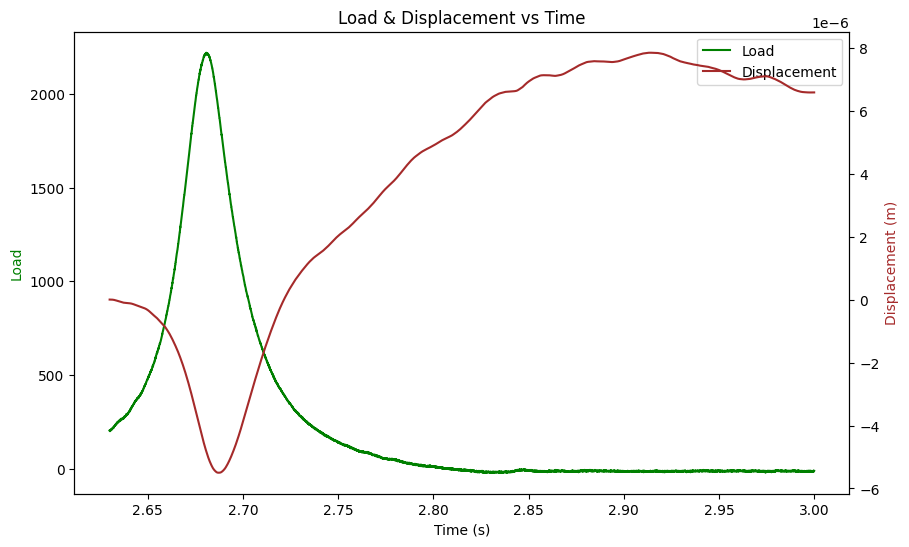

In [34]:
# --- Load & Displacement vs Time ---
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(df["Time (s)"], df["Load"], color="green", label="Load")
ax2.plot(df["Time (s)"], df["Disp (m)"], color="brown", label="Displacement")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Load", color="green")
ax2.set_ylabel("Displacement (m)", color="brown")
plt.title("Load & Displacement vs Time")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.show()

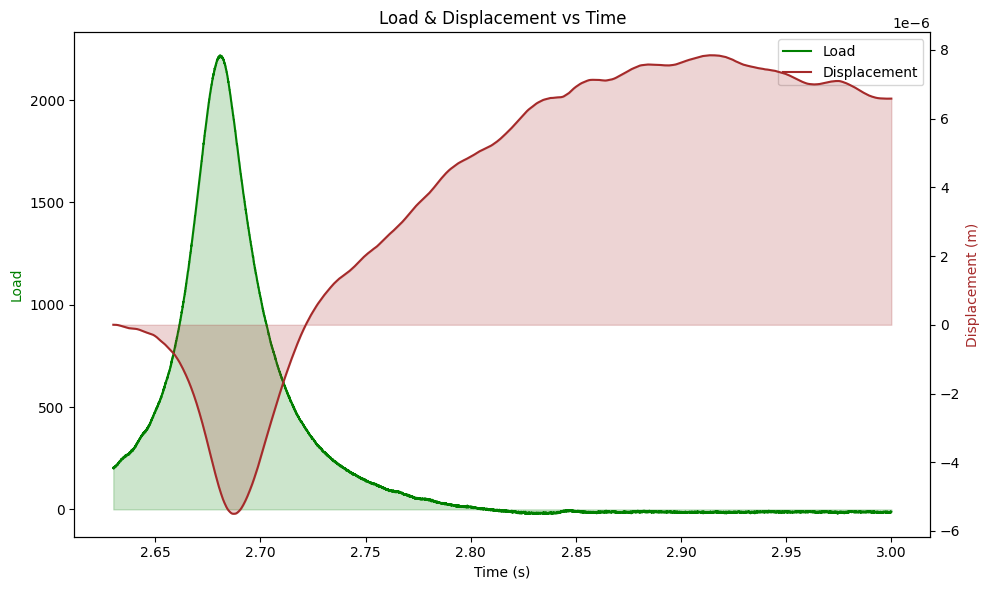

In [35]:
# --- Load & Displacement vs Time (with filled areas) ---
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Plot Load on left y-axis
ax1.plot(df["Time (s)"], df["Load"], color="green", label="Load")
ax1.fill_between(df["Time (s)"], df["Load"], color="green", alpha=0.2)

# Plot Displacement on right y-axis
ax2.plot(df["Time (s)"], df["Disp (m)"], color="brown", label="Displacement")
ax2.fill_between(df["Time (s)"], df["Disp (m)"], color="brown", alpha=0.2)

# Labels and title
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Load", color="green")
ax2.set_ylabel("Displacement (m)", color="brown")
plt.title("Load & Displacement vs Time")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()


In [36]:
# Save the updated DataFrame to a new sheet in the same Excel file
with pd.ExcelWriter('RPLTResults.xlsx', mode='a', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='results', index=False)